In [18]:
# importuri

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LassoCV, Lasso, RidgeCV, Ridge
from sklearn.impute import SimpleImputer

from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression


In [3]:
# date

train = pd.read_csv("train.csv")
X = train.drop(columns=["SalePrice"])
y = train["SalePrice"]
y_log = np.log1p(y)  # stabilizare scara

In [4]:
# separare tipuri de variabile

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

num_cols, cat_cols


(['Id',
  'MSSubClass',
  'LotFrontage',
  'LotArea',
  'OverallQual',
  'OverallCond',
  'YearBuilt',
  'YearRemodAdd',
  'MasVnrArea',
  'BsmtFinSF1',
  'BsmtFinSF2',
  'BsmtUnfSF',
  'TotalBsmtSF',
  '1stFlrSF',
  '2ndFlrSF',
  'LowQualFinSF',
  'GrLivArea',
  'BsmtFullBath',
  'BsmtHalfBath',
  'FullBath',
  'HalfBath',
  'BedroomAbvGr',
  'KitchenAbvGr',
  'TotRmsAbvGrd',
  'Fireplaces',
  'GarageYrBlt',
  'GarageCars',
  'GarageArea',
  'WoodDeckSF',
  'OpenPorchSF',
  'EnclosedPorch',
  '3SsnPorch',
  'ScreenPorch',
  'PoolArea',
  'MiscVal',
  'MoSold',
  'YrSold'],
 ['MSZoning',
  'Street',
  'Alley',
  'LotShape',
  'LandContour',
  'Utilities',
  'LotConfig',
  'LandSlope',
  'Neighborhood',
  'Condition1',
  'Condition2',
  'BldgType',
  'HouseStyle',
  'RoofStyle',
  'RoofMatl',
  'Exterior1st',
  'Exterior2nd',
  'MasVnrType',
  'ExterQual',
  'ExterCond',
  'Foundation',
  'BsmtQual',
  'BsmtCond',
  'BsmtExposure',
  'BsmtFinType1',
  'BsmtFinType2',
  'Heating',
  'Hea

In [6]:
# transformari 

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [7]:
# categorical pipeline

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# full pipeline

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

In [8]:
# LassoCV: cauta automat alpha (λ) pe grila logaritmică


alphas_lasso = np.logspace(-4, 2, 50)  # 1e-4 ... 1e2

lasso_cv = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LassoCV(alphas=alphas_lasso, cv=5, max_iter=200_000, n_jobs=-1))
])

lasso_cv.fit(X, y_log)
best_alpha_lasso = lasso_cv.named_steps["model"].alpha_
best_alpha_lasso

np.float64(0.0005428675439323859)

In [11]:
# RidgeCV: cauta automat alpha (λ)


alphas_ridge = np.logspace(-4, 3, 60)  # 1e-4 ... 1e3

ridge_cv = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RidgeCV(alphas=alphas_ridge, cv=5, scoring="neg_mean_squared_error"))
])

ridge_cv.fit(X, y_log)
best_alpha_ridge = ridge_cv.named_steps["model"].alpha_
best_alpha_ridge

np.float64(16.608827826277167)

In [13]:
# evaluare pe hold-out (train/test split), pe scala originala a pretului


X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# modele finale cu alpha optim
model_lasso_final = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Lasso(alpha=best_alpha_lasso, max_iter=200_000))
])

model_ridge_final = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=best_alpha_ridge))
])


In [14]:
from sklearn.metrics import root_mean_squared_error, r2_score

In [15]:
# antrenare
model_lasso_final.fit(X_train, y_train_log)
model_ridge_final.fit(X_train, y_train_log)

# predictii pe setul de test (log -> înapoi pe scala originală)
pred_lasso_log = model_lasso_final.predict(X_test)
pred_ridge_log = model_ridge_final.predict(X_test)

y_test = np.expm1(y_test_log)
pred_lasso = np.expm1(pred_lasso_log)
pred_ridge = np.expm1(pred_ridge_log)

# metrici pe scala originala


rmse_lasso = root_mean_squared_error(y_test, pred_lasso)
rmse_ridge = root_mean_squared_error(y_test, pred_ridge)

r2_lasso = r2_score(y_test, pred_lasso)
r2_ridge = r2_score(y_test, pred_ridge)

rmse_lasso, r2_lasso, rmse_ridge, r2_ridge

(22786.14880279953, 0.9323094529178144, 25440.26850919048, 0.9156219377979945)

In [16]:

# nr de coeficienți nenuli pentru Lasso 

# antrenare pe tot setul pentru raportarea ponderii
lasso_full = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Lasso(alpha=best_alpha_lasso, max_iter=200_000))
]).fit(X, y_log)

coef = lasso_full.named_steps["model"].coef_
np.count_nonzero(coef), coef.size


(np.int64(114), 304)

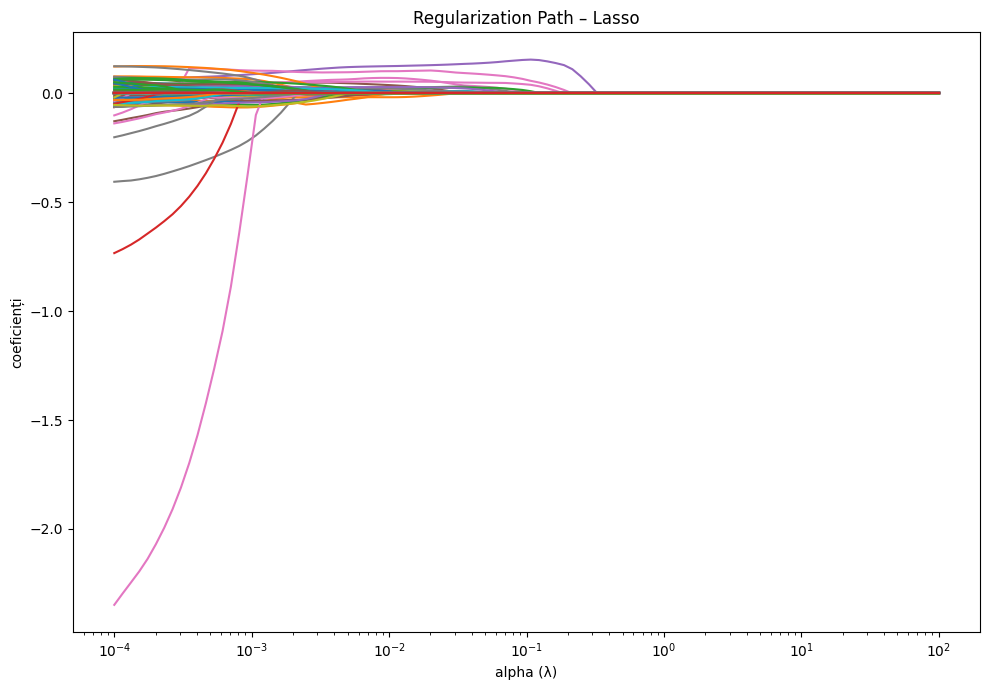

In [19]:
# Lasso – regularization path
alphas_lasso_path = np.logspace(-4, 2, 100)
lasso_coefs = []

for a in alphas_lasso_path:
    model = Pipeline([
        ("prep", preprocess),
        ("lasso", Lasso(alpha=a, max_iter=200000))
    ])
    model.fit(X, y_log)
    lasso_coefs.append(model.named_steps["lasso"].coef_)

lasso_coefs = np.array(lasso_coefs)

plt.figure(figsize=(10,7))
plt.plot(alphas_lasso_path, lasso_coefs)
plt.xscale("log")
plt.xlabel("alpha (λ)")
plt.ylabel("coeficienți")
plt.title("Regularization Path – Lasso")
plt.tight_layout()
plt.show()
